# Evaluate **Paraphrasing**

Our imposter approach needs models to reword an original text keeping the same meaning.
Ideally, we want to model the way texts originated.
This is dependent on the text's genre, i.e. a student essay originates from a task description and a list of URLs while a new article originates from a list of additional sources or from spectating an event.
We implemented both a naive approach to rewording a text and a more sophisticated one:
- given a prompt and a text, the naive approach uses a language model to paraphrase the text
- given a prompt and a text LLM A is used to extract the text's genre, tone and summary of bullet points, then LLM B is used to reword the text in the same genre and tone based on the summary of bullet points

In [1]:
from pathlib import Path
import os
import textwrap
import sys

# Add the root of the project to Python path
sys.path.append(os.path.abspath(".."))
from config import CONFIG
from genai_detection.paraphrasing.paraphraser import (
    T5ChatGPTParaphraser,
    T5GooglePAWSParaphraser,
    BlabladorParaphraser,
    BulletPointParaphraser,
    OllamaParaphraser,
    ParaphrasingEvaluator,
    TaskParaphraser,
    TopicParaphraser,
    TitleParaphraser,
)

/Users/klara/Library/Caches/pypoetry/virtualenvs/generative-ai-detection-PkLo9Jli-py3.11/lib/python3.11/site-packages/pyemd/__init__.py:74: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from .emd import emd, emd_with_flow, emd_samples
[nltk_data] Downloading package wordnet to /Users/klara/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Original text
We use a CNN news article from 23.06.2025/ 04.07.2025 as an example.

In [2]:
path2datasets = (
    Path(os.getcwd()).resolve().parent / "data" / "datasets" / "custom_texts"
)
data_category = "News"  # This is used for plot titles in the notebook
path2results = Path(os.getcwd()).resolve().parent / CONFIG.SAVE_PATH / "paraphrasing"
assert path2datasets.exists(), f"Path to datasets {path2datasets} does not exist."
# file_name = "cnn_230625"    # USA attacks Iran
file_name = "cnn_040725"  # Dalai Lama
original_text = open(path2datasets / f"{file_name}.txt").read()

print(textwrap.fill(original_text, width=80))

  For much of the past century, the Dalai Lama has been the living embodiment of
Tibet’s struggle for greater freedoms under Chinese Communist Party rule,
sustaining the cause from exile even as an increasingly powerful Beijing has
become ever more assertive in suppressing it.  As his 90th birthday approaches
this Sunday, the spiritual leader for millions of followers of Tibetan Buddhism
worldwide is bracing for a final showdown with Beijing: the battle over who will
control his reincarnation.  On Wednesday, the Dalai Lama announced that he will
have a successor after his death, and that his office will have the sole
authority to identify his reincarnation.  “I am affirming that the institution
of the Dalai Lama will continue,” the Nobel Peace laureate said in a video
message to religious elders gathering in Dharamshala, India, where he has found
refuge since Chinese communist troops put down an armed uprising in his
mountainous homeland in 1959.  The cycle of rebirth lies at the core 

## Naive Approach

In [3]:
ollama_version = "zephyr:7b"  # "mistral:7b"  # "default:latest"
paraphrasers = {
    "T5_ChatGPT": T5ChatGPTParaphraser(),
    "T5_Google_PAWS": T5GooglePAWSParaphraser(),
    # "Blablador": BlabladorParaphraser(
    #     model_id="1 - Llama3 405 the best general model and big context size"
    # ),
    "Ollama": OllamaParaphraser(model_id=ollama_version),
}
if "Blablador" in paraphrasers.keys():
    print(
        "Available Blablador models:\n",
        paraphrasers["Blablador"]._get_available_models(verbose=False),
    )

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [ ]:
n_responses = 1  # number of paraphrases to generate
max_length = 512  # Maximum length of the generated paraphrase
temperature = 0.7  # Controls the randomness of the output. Lower values make the output more deterministic.

prompts = [
    "Paraphrase the text above and output only the paraphrased version.",
    "For the text above: First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts).",
    "For the text above: Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.",
    "For the text above: Paraphrase the sentence using the same tone as the original with approximately the same number of words.",
    "For the text above: Paraphrase this sentence. Do not change the meaning, but use different words and structure. Output only the paraphrased sentence.",
]

## Bullet Point Approach

Ollama models are by far the best ones for extracting the genre, tone and summary of bullet points and returning them in a structured way.
Hence, we use the Ollama model as the text extractor and any other model as the text generator.

In [5]:
models = {
    "text_extractor": {
        "name": "Ollama-latest",
        "model": OllamaParaphraser(model_id=ollama_version),
    },
    "text_generator": {
        "name": "Ollama-latest",
        "model": OllamaParaphraser(model_id=ollama_version),
    },
}
bullet_point_paraphraser = BulletPointParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Task Paraphraser
The task paraphraser extracts the task, tone and genre from the text and then generates a paraphrase based on this information.

In [6]:
task_paraphraser = TaskParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Topic Paraphraser
The topic paraphraser extracts the topic, tone and genre from the text and then generates a paraphrase based on this information.

In [7]:
topic_paraphraser = TopicParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Title Paraphraser
The title paraphraser extracts the title, tone and genre from the text and then generates a paraphrase based on this information.

In [8]:
title_paraphraser = TitleParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Evaluating the Approaches

In [9]:
paraphrasers.update(
    {
        "BulletPoint": bullet_point_paraphraser,
        "Task": task_paraphraser,
        "Topic": topic_paraphraser,
        "Title": title_paraphraser,
    }
)
paraphrase_evaluator = ParaphrasingEvaluator(
    paraphrasers=paraphrasers,
    prompts=prompts,
    original_text=original_text,
    n_responses=n_responses,
    max_length=max_length,
    temperature=temperature,
)
df, extremest_paraphrases = paraphrase_evaluator.evaluate(
    save_extremest_paraphr_per_score=True, save_to_disk=True
)
display(df)

[DEBUG] Total configurations to evaluate: 7, [(('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x10734eb50>), 'Paraphrase the text above and output only the paraphrased version.', 0.7), (('T5_Google_PAWS', <genai_detection.paraphrasing.paraphraser.T5GooglePAWSParaphraser object at 0x360b91dd0>), 'Paraphrase the text above and output only the paraphrased version.', 0.7), (('Ollama', <genai_detection.paraphrasing.paraphraser.OllamaParaphraser object at 0x35763bf50>), 'Paraphrase the text above and output only the paraphrased version.', 0.7), (('BulletPoint', <genai_detection.paraphrasing.paraphraser.BulletPointParaphraser object at 0x35763b610>), None, 0.0), (('Task', <genai_detection.paraphrasing.paraphraser.TaskParaphraser object at 0x36246e7d0>), None, 0.0), (('Topic', <genai_detection.paraphrasing.paraphraser.TopicParaphraser object at 0x360adc950>), None, 0.0), (('Title', <genai_detection.paraphrasing.paraphraser.TitleParaphraser object at 0x3

Evaluating Paraphrasers:  71%|███████▏  | 5/7 [01:41<00:46, 23.24s/it]

Again
Again
Again


Evaluating Paraphrasers: 100%|██████████| 7/7 [02:19<00:00, 19.90s/it]

Results saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_results_comparison_temp0.7_maxLength512.csv


,model,prompt,parameters,original_text,paraphrased_text,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,bertscore_hash,sem_sim_avg,syn_sim_avg,gohsen_delta
0,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,0.042414,0.815275,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066
1,T5_Google_PAWS,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",the dalai lama announced on wednesday that he ...,3.746927e-04,0.081152,0.199697,0.139605,0.160363,0.160363,0.862216,0.740206,0.796566,0.176135,0.920940,distilbert-base-uncased_L5_no-idf_version=0.3....,0.699213,0.120145,0.579067
2,Ollama,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","the dalai lama, a prominent spiritual leader f...",1.142614e-01,0.301464,0.518160,0.383495,0.401937,0.401937,0.865698,0.808655,0.836205,0.294595,0.916697,distilbert-base-uncased_L5_no-idf_version=0.3....,0.744370,0.344786,0.399584
3,BulletPoint,None <TEXT>,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","the dalai lama, one of the world's most revere...",1.149503e-01,0.282357,0.517842,0.176226,0.189212,0.189212,0.824197,0.804584,0.814272,0.256128,0.923205,distilbert-base-uncased_L5_no-idf_version=0.3....,0.724477,0.274001,0.450476
4,Task,None <TEXT>,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",as tensions continue to escalate between china...,4.236862e-02,0.248837,0.415730,0.096463,0.166934,0.166934,0.792126,0.770961,0.781400,0.197967,0.893784,distilbert-base-uncased_L5_no-idf_version=0.3....,0.687248,0.208344,0.478903
5,Topic,None <TEXT>,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",as tensions continue to rise between china and...,5.949833e-02,0.255048,0.445438,0.109319,0.180680,0.180680,0.798335,0.789075,0.793678,0.213285,0.892251,distilbert-base-uncased_L5_no-idf_version=0.3....,0.697325,0.228539,0.468786


In [10]:
df["paraphrased_text"].values

array(['despite the challenges of political unrest in tibet, the dalai lama has emerged as one of the most influential figures in tibetan buddhism.',
       'the dalai lama announced on wednesday that he will be a successor under chinese communist party rule and will have sole authority to identify his reincarnation. the dalai lama has not only contributed to the battle of tibetan buddhism, but it has also become a historic battleground for the future of the country, which is defined by a distinct language, culture, religion and way of life that imposes criticism on beijing.',
       "the dalai lama, a prominent spiritual leader for tibetan buddhists worldwide and a symbol of tibet's struggle for greater freedoms under chinese communist rule, is preparing for a final showdown with beijing over who will succeed him after his death. the reincarnation of the current dalai lama has become a battleground for the future of tibet, as china claims authority to approve all reincarnations of liv

### Extremest (i.e. best and worst) paraphrases per metric

In [11]:
display(extremest_paraphrases)

,model,prompt,parameters,original_text,paraphrased_text,bleu_score,meteor_score,rouge1,rouge2,rougeL,...,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,bertscore_hash,sem_sim_avg,syn_sim_avg,gohsen_delta,metric,extreme
0,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,bleu_score,min
1,BulletPoint,None <TEXT>,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","the dalai lama, one of the world's most revere...",1.149503e-01,0.282357,0.517842,0.176226,0.189212,...,0.804584,0.814272,0.256128,0.923205,distilbert-base-uncased_L5_no-idf_version=0.3....,0.724477,0.274001,0.450476,bleu_score,max
2,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,meteor_score,min
3,Ollama,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","the dalai lama, a prominent spiritual leader f...",1.142614e-01,0.301464,0.518160,0.383495,0.401937,...,0.808655,0.836205,0.294595,0.916697,distilbert-base-uncased_L5_no-idf_version=0.3....,0.744370,0.344786,0.399584,meteor_score,max
4,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,rouge1,min
5,Ollama,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","the dalai lama, a prominent spiritual leader f...",1.142614e-01,0.301464,0.518160,0.383495,0.401937,...,0.808655,0.836205,0.294595,0.916697,distilbert-base-uncased_L5_no-idf_version=0.3....,0.744370,0.344786,0.399584,rouge1,max
6,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,rouge2,min
7,Ollama,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","the dalai lama, a prominent spiritual leader f...",1.142614e-01,0.301464,0.518160,0.383495,0.401937,...,0.808655,0.836205,0.294595,0.916697,distilbert-base-uncased_L5_no-idf_version=0.3....,0.744370,0.344786,0.399584,rouge2,max
8,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,rougeL,min
9,Ollama,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","the dalai lama, a prominent spiritual leader f...",1.142614e-01,0.301464,0.518160,0.38349

In [12]:
print("### Extremest (i.e. best and worst) paraphrases per metric")
print("Original text:")
print(textwrap.fill(original_text[:200], width=80), "...")

for index, row in extremest_paraphrases.iterrows():
    print(f"Metric: {row['extreme']} {row['metric']}")
    print(
        f"Paraphrase by {row['model']}: {textwrap.fill(row['paraphrased_text'], width=80)}"
    )
    # print(f"Prompt: {row['prompt']}")
    print("-" * 80)

### Extremest (i.e. best and worst) paraphrases per metric
Original text:
  For much of the past century, the Dalai Lama has been the living embodiment of
Tibet’s struggle for greater freedoms under Chinese Communist Party rule,
sustaining the cause from exile even as an in ...
Metric: min bleu_score
Paraphrase by T5_ChatGPT: despite the challenges of political unrest in tibet, the dalai lama has emerged
as one of the most influential figures in tibetan buddhism.
--------------------------------------------------------------------------------
Metric: max bleu_score
Paraphrase by BulletPoint: the dalai lama, one of the world's most revered religious leaders, has announced
that he will have a successor after his death and that his office will hold sole
authority in identifying the next reincarnation. the move, made as the spiritual
leader approaches his 90th birthday, has significant implications for tibetan
buddhism and the broader himalayan region, with geopolitical consequences. the
d

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_metrics_grouped_by_model_radar_chart_20250722_220611.png


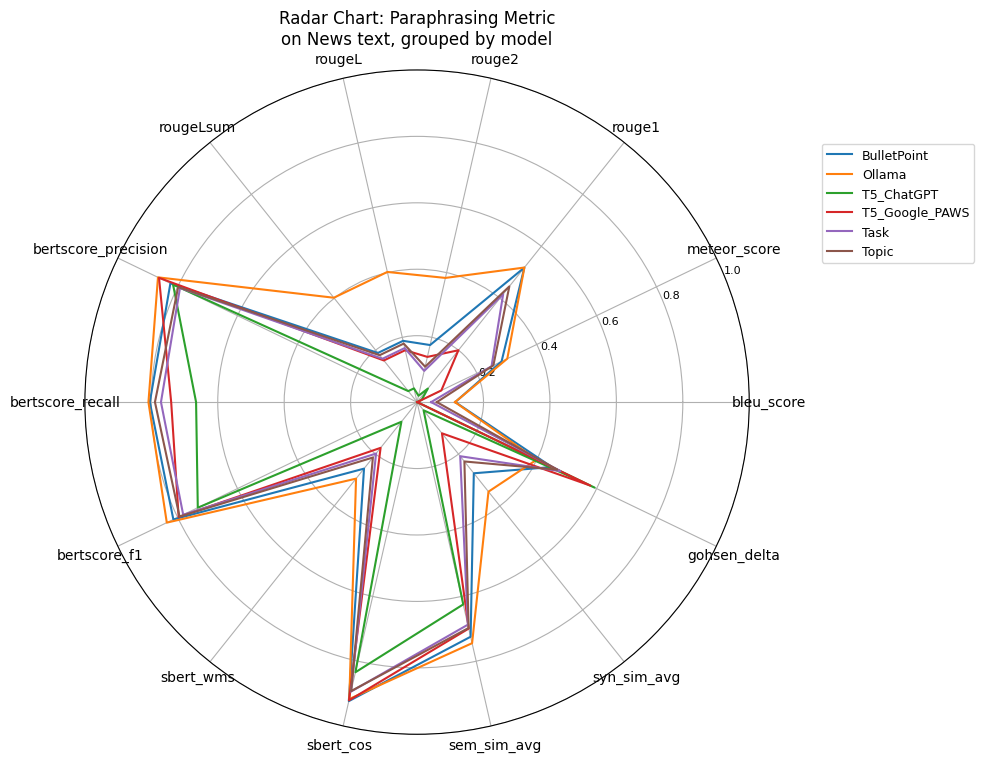

In [13]:
paraphrase_evaluator.plot_models_metrics(
    df=df, save_path=path2results, data_category=data_category, group_by="model"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_metrics_grouped_by_prompt_radar_chart_20250722_220612.png


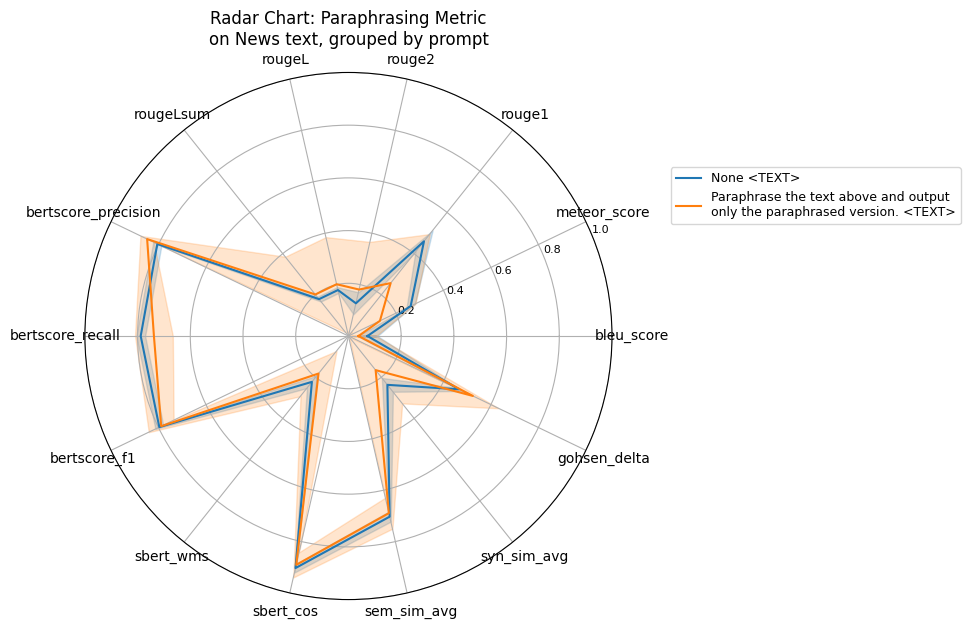

In [14]:
paraphrase_evaluator.plot_models_metrics(
    df=df, save_path=path2results, data_category=data_category, group_by="prompt"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/sem_syn_scatter_grouped_by_model_20250722_220612.png


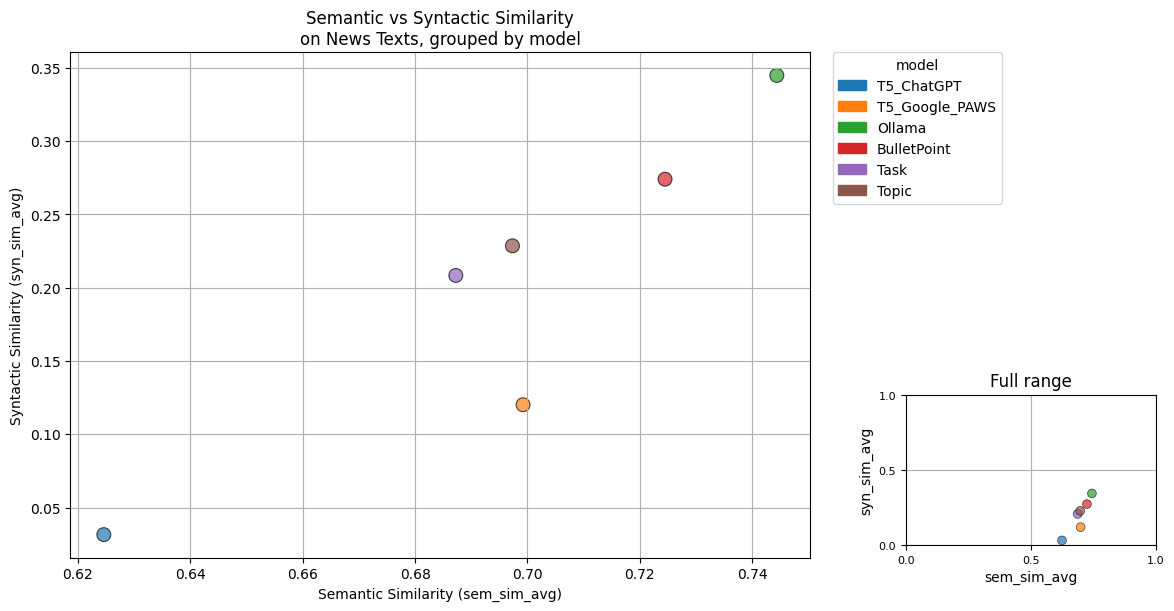

In [15]:
paraphrase_evaluator.plot_metric_scatter(
    df, save_path=path2results, data_category=data_category, group_by="model"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/sem_syn_scatter_grouped_by_prompt_20250722_220612.png


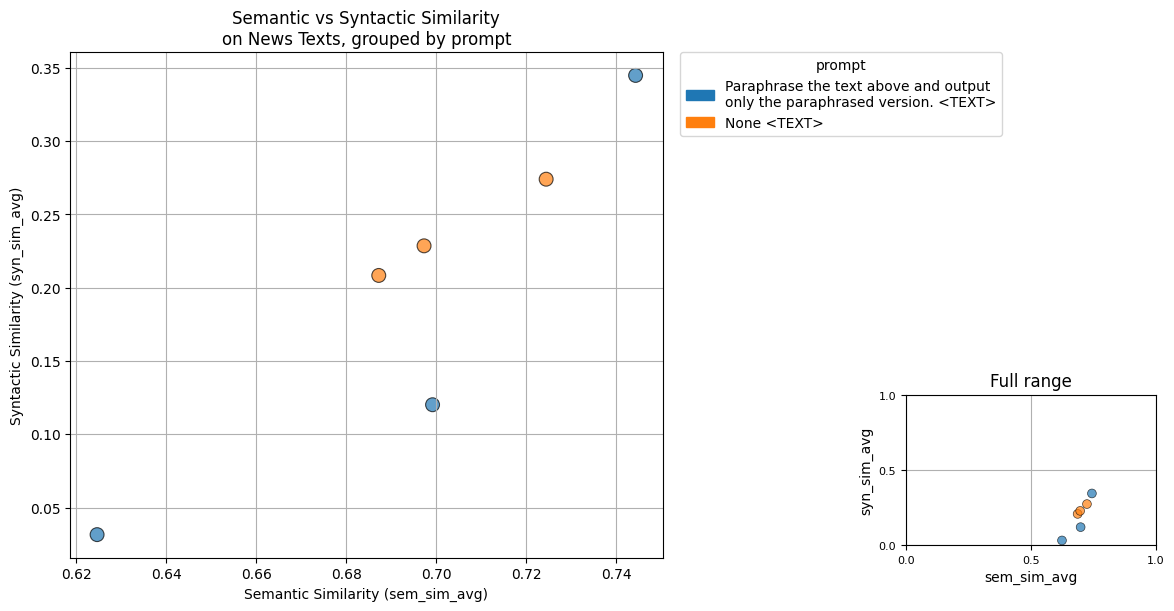

In [16]:
paraphrase_evaluator.plot_metric_scatter(
    df, save_path=path2results, data_category=data_category, group_by="prompt"
)

### Kernel Density Estimation (KDE)
- KDE estimates probability density PDF
- The y-axis is density/ concentration/ likelihood, not probability.
- Density can be greater than 1 if data are tightly clustered in a small range.
- For example, if many data points lie very close together, the curve can be sharp and tall (high density), so y-values exceed 1.
- The important property is that the **integral (area) under the curve is 1**, not that the max height is ≤1.

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/metric_distributions_grouped_by_model_20250722_220613.png


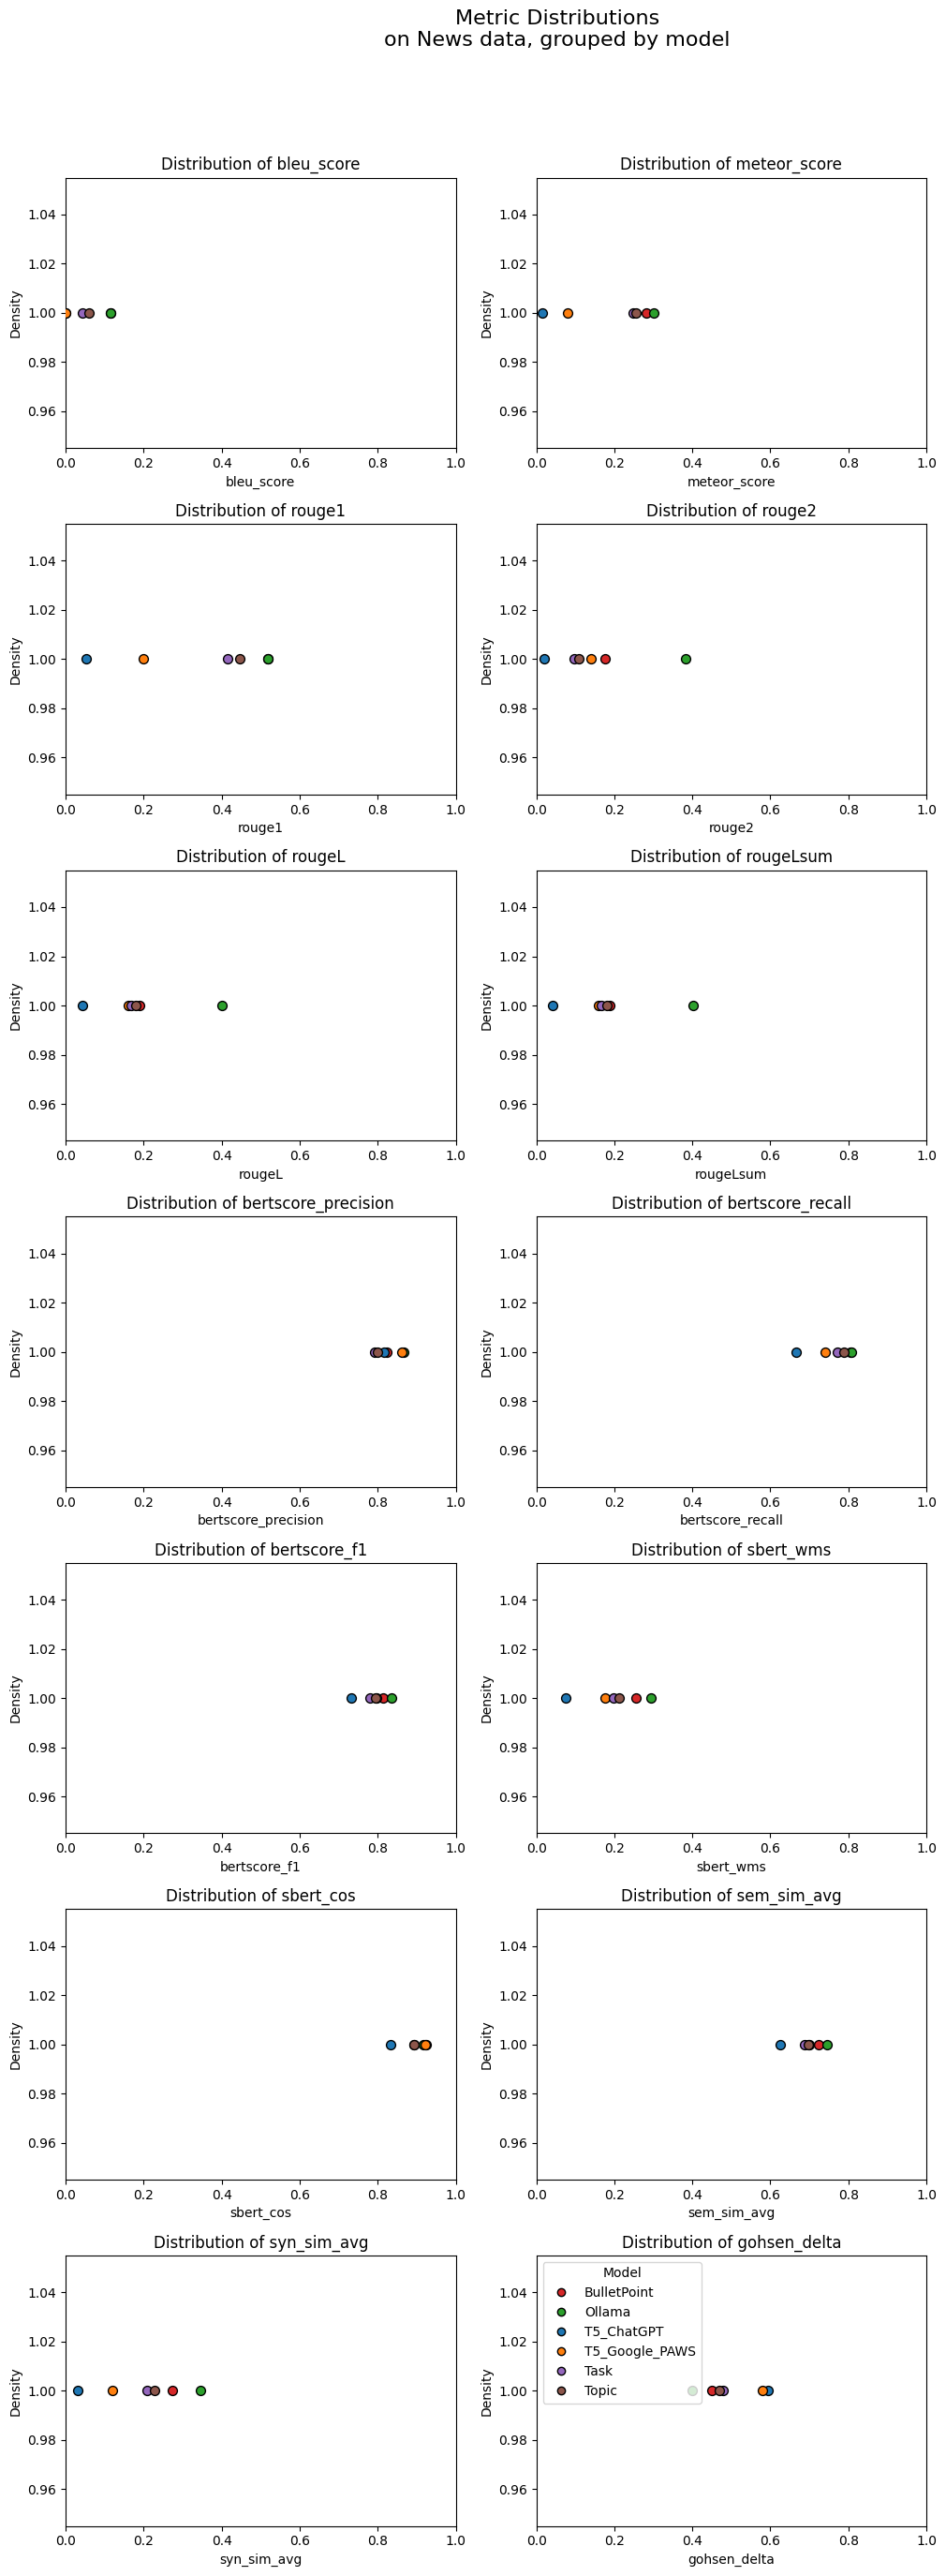

In [17]:
paraphrase_evaluator.plot_metric_distributions(
    df, save_path=path2results, data_category=data_category, group_by="model"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/metric_distributions_grouped_by_prompt_20250722_220615.png


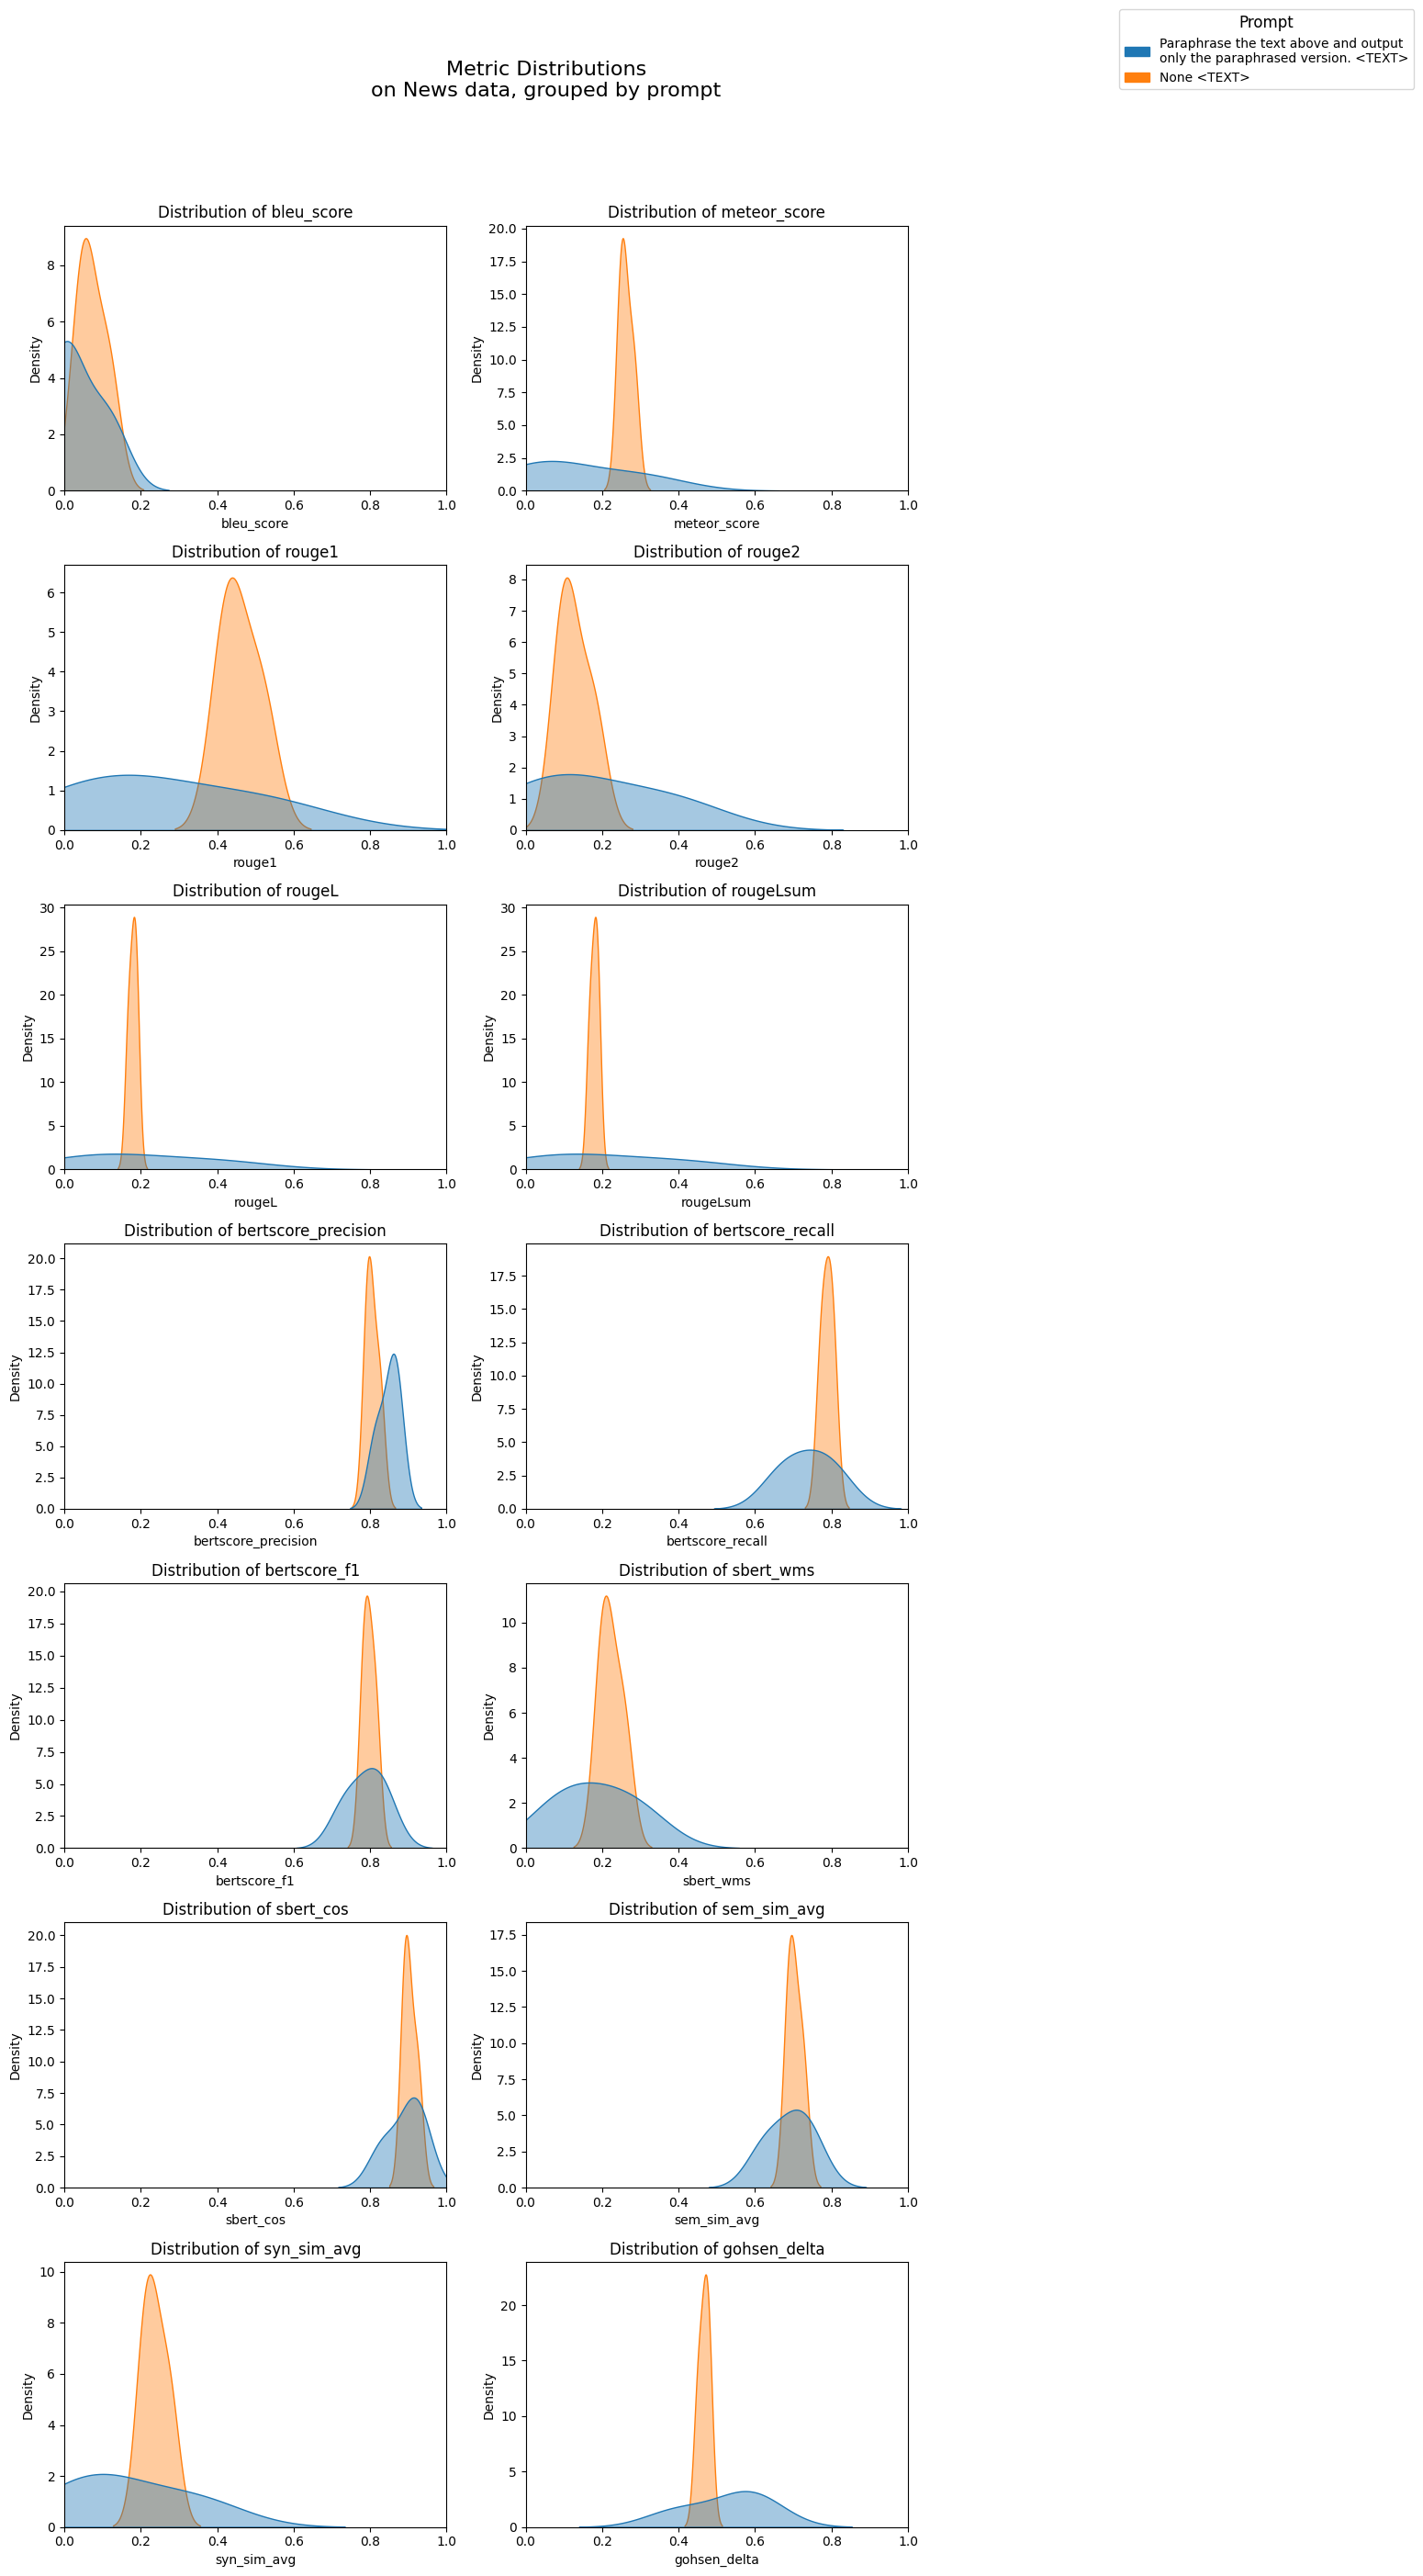

In [18]:
paraphrase_evaluator.plot_metric_distributions(
    df, save_path=path2results, data_category=data_category, group_by="prompt"
)

# Evaluation for text extractor of Non-Naive Paraphrasers

In [19]:
n_responses = 3  # number of paraphrases to generate
paraphrasers = {
    # "Ollama": OllamaParaphraser(model_id=ollama_version),
    "TopicParaphraser": TopicParaphraser(
        text_extractor=OllamaParaphraser(model_id=ollama_version),
        text_generator=OllamaParaphraser(model_id=ollama_version),
    ),
    # "TaskParaphraser": TaskParaphraser(
    #     text_extractor=OllamaParaphraser(model_id=ollama_version),
    #     text_generator=OllamaParaphraser(model_id=ollama_version),
    # ),
    # "TitleParaphraser": TitleParaphraser(
    #     text_extractor=OllamaParaphraser(model_id=ollama_version),
    #     text_generator=OllamaParaphraser(model_id=ollama_version),
    # ),
    # "BulletPointParaphraser": BulletPointParaphraser(
    #     text_extractor=OllamaParaphraser(model_id=ollama_version),
    #     text_generator=OllamaParaphraser(model_id=ollama_version),
    # ),
}
evaluator = ParaphrasingEvaluator(
    paraphrasers=paraphrasers,
    prompts=[
        "Paraphrase the following text and output only the paraphrased version:"
    ],  # use a single prompt for simplicity
    original_text="not used",  # self.base_dir contains fixed texts to test on
    n_responses=n_responses,
    max_length=max_length,
    temperature=temperature,
    config={"save_path": path2results},
)

In [20]:
# evaluator.evaluate_extractors(save_to_disk=True)

In [21]:
import numpy as np
import pandas as pd

dfs = {}
for dataset in evaluator.base_dirs.keys():
    df = pd.read_csv(path2results / f"extractor_eval_results_{dataset}.csv")
    df["length_diff"] = [
        ((p - o) / o) if o > 0 else 0
        for o, p in zip(df["original_length"], df["paraphrase_length"])
    ]  # between 0 and 1

    df["dataset"] = dataset
    dfs[dataset] = df

# Long / tidy combined DataFrame
df_all = pd.concat(dfs.values(), ignore_index=True)

In [22]:
import datetime
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import patches as mpatches


def _wrap_label(label: str, words_per_line: int = 6) -> str:
    assert (
        isinstance(words_per_line, int) and words_per_line > 0
    ), "words_per_line must be a positive integer."
    words = str(label).split()
    return "\n".join(
        [
            " ".join(words[i : i + words_per_line])
            for i in range(0, len(words), words_per_line)
        ]
    )


def plot_metric_kdes_per_dataset(
    df_all: pd.DataFrame,
    metrics: list[str],
    save_path: Path | None = None,
    data_category: str | None = None,
    dataset_col: str = "dataset",
):
    # Filter valid metrics
    metrics = [
        m
        for m in metrics
        if m in df_all.columns and pd.api.types.is_numeric_dtype(df_all[m])
    ]
    assert metrics, "No numeric metrics found to plot."

    unique_labels = pd.unique(df_all[dataset_col])
    palette = sns.color_palette("tab10", n_colors=len(unique_labels))
    label_to_color = {
        lbl: palette[i % len(palette)] for i, lbl in enumerate(unique_labels)
    }

    n = len(metrics)
    n_cols = 2
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]
        sub_df = df_all[[dataset_col, metric]].dropna()

        # KDE per dataset
        sns.kdeplot(
            data=sub_df,
            x=metric,
            hue=dataset_col,
            fill=True,
            common_norm=False,
            alpha=0.4,
            palette=label_to_color,
            ax=ax,
            legend=False,
        )

        # Scatter single-value datasets (if any)
        counts = sub_df.groupby(dataset_col)[metric].count()
        singles = counts[counts == 1].index

        for dataset_name in singles:
            val = sub_df[sub_df[dataset_col] == dataset_name][metric].iloc[0]
            ax.scatter(
                val,
                0.1,  # y offset to show scatter
                color=label_to_color[dataset_name],
                s=50,
                edgecolor="k",
                label=dataset_name,  # ensure it appears in legend
                zorder=5,
            )
        legend_patches = [
            mpatches.Patch(color=color, label=_wrap_label(label))
            for label, color in label_to_color.items()
        ]
        fig.legend(
            handles=legend_patches,
            loc="upper left",
            bbox_to_anchor=(1.02, 1),  # outside the plot on right
            title="Dataset",
            frameon=True,
            borderaxespad=0,
            fontsize=10,
            title_fontsize=12,
        )

        ax.set_title(metric)
        ax.set_xlim(sub_df[metric].min(), sub_df[metric].max())
        ax.set_xlabel(metric)
        ax.set_ylabel("Density")

        # Remove duplicate labels in legend
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, loc="upper right", frameon=True)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    title = (
        f"KDE Metric Distributions by Dataset\non {data_category} data"
        if data_category
        else "KDE Metric Distributions by Dataset"
    )
    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path:
        save_path = Path(save_path)
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        save_path.mkdir(parents=True, exist_ok=True)
        out = save_path / f"kde_metric_dists_{timestamp}.png"
        fig.savefig(out, bbox_inches="tight")
        print(f"Saved KDE grid to {out}")

    plt.show()

/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_50613/4173351026.py:54: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_50613/4173351026.py:54: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


Saved KDE grid to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/kde_metric_dists_20250722_220634.png


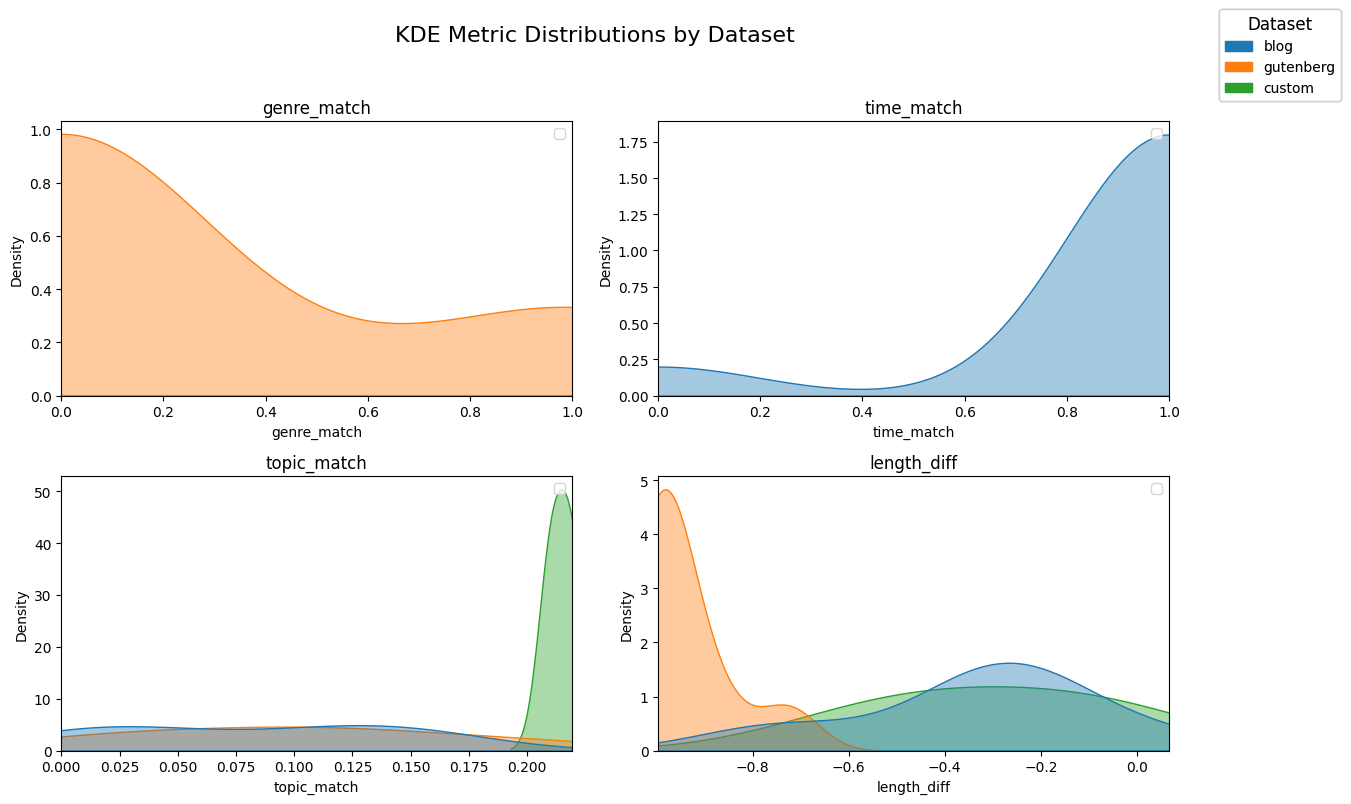

In [23]:
metrics = ["genre_match", "time_match", "topic_match", "length_diff"]
save_path = path2results
plot_metric_kdes_per_dataset(df_all, metrics, save_path=path2results)

`length_diff` is perceptual difference in length between original and paraphrased text, where negative values indicate that the paraphrased text is shorter than the original text.

## Batch Processing

In [24]:
# Batch paraphrasing
# texts = ["The sky is blue.", "I love programming.", "Artificial intelligence is fascinating."]
# paraphrased_batch = bullet_point_paraphraser.paraphrase_batch(texts)
# for original, paraphrased in zip(texts, paraphrased_batch):
#     print(f"Original: {original} | Paraphrased: {paraphrased}")

In [25]:
import dirtyjson

d = dirtyjson.loads(
    """["foo", /* not fu*/ {bar: ['baz', null, 1.0, 2,]}] and then ignore this junk"""
)
d

['foo', AttributedDict([('bar', ['baz', None, 1.0, 2])])]